# 07 — Panel Granger Causality  *(corrected)*

**Critical correction:** The pooled panel F-test for crisis onset now uses CRISIS ONSET own-lags as controls in the restricted model (not credit growth lags). The previous version was misspecified.

Per-country Granger tests (Cell 3) are unaffected — they were correctly specified.


## Cell 1 — Imports and Load

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy import stats

BASE    = Path(r'C:\Users\Owner\OneDrive\dissertation')
DATA_IN = BASE/'data'/'processed'/'jst_sentiment_master.csv'
OUT_DIR = BASE/'data'/'processed'
FIG_DIR = BASE/'figures'/'sentiment_improved'
FIG_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_IN.exists(), f'Not found: {DATA_IN}'
df = pd.read_csv(DATA_IN)
df = df.sort_values(['iso','year']).reset_index(drop=True)
df.columns = df.columns.str.strip()

print(f'Shape     : {df.shape}')
print(f'Countries : {df["iso"].nunique()}')
print(f'Years     : {df["year"].min()} - {df["year"].max()}')

req = ['iso','year','crisisjst','tloans','P_neg']
missing = [c for c in req if c not in df.columns]
if missing: print(f'WARNING: Missing: {missing}  Re-run NB04 first')
else: print('All required columns present')

Shape     : (432, 95)
Countries : 18
Years     : 1997 - 2020
All required columns present


## Cell 2 — Prepare variables

In [3]:
# Credit growth (the macro outcome variable for Test 1)
df['tloans_gr'] = df.groupby('iso')['tloans'].pct_change()

# Use raw P_neg (grangercausalitytests handles lags internally)
SENT_COL = 'P_neg'

print('Variables prepared:')
print(f'  Predictor : {SENT_COL}')
print(f'  Outcome 1 : tloans_gr (credit growth)')
print(f'  Outcome 2 : crisisjst (crisis onset)')
print()
for col in [SENT_COL,'tloans_gr','crisisjst']:
    if col in df.columns:
        print(f'{col}: mean={df[col].mean():.4f} std={df[col].std():.4f} NaN={df[col].isna().sum()}')

Variables prepared:
  Predictor : P_neg
  Outcome 1 : tloans_gr (credit growth)
  Outcome 2 : crisisjst (crisis onset)

P_neg: mean=0.1789 std=0.1028 NaN=0
tloans_gr: mean=0.0515 std=0.0670 NaN=18
crisisjst: mean=0.0324 std=0.1773 NaN=0


## Cell 3 — Per-Country Granger Tests

For each country, tests H0: 'P_neg does NOT Granger-cause [outcome]' at lags 1 and 2.
The F-test compares restricted (own lags only) vs unrestricted (own + sentiment lags) models.


In [5]:
MAX_LAGS = 2
MIN_OBS  = 10
OUTCOME_COLS = {'tloans_gr':'Credit growth', 'crisisjst':'Crisis onset'}

granger_records = []

for country in sorted(df['iso'].unique()):
    sub = df[df['iso']==country][['year',SENT_COL,'tloans_gr','crisisjst']].dropna()
    if len(sub) < MIN_OBS:
        print(f'  {country}: only {len(sub)} obs - skip'); continue
    row = {'country':country, 'n_obs':len(sub)}
    for ocol, olabel in OUTCOME_COLS.items():
        test_data = sub[[ocol, SENT_COL]].dropna()
        if len(test_data) < MIN_OBS or test_data[ocol].std() == 0:
            row[f'p_lag1_{ocol}'] = np.nan
            row[f'p_lag2_{ocol}'] = np.nan
            row[f'f_lag2_{ocol}'] = np.nan
            continue
        try:
            res = grangercausalitytests(test_data, maxlag=MAX_LAGS, verbose=False)
            row[f'p_lag1_{ocol}'] = res[1][0]['ssr_ftest'][1]
            row[f'p_lag2_{ocol}'] = res[2][0]['ssr_ftest'][1]
            row[f'f_lag2_{ocol}'] = res[2][0]['ssr_ftest'][0]
        except Exception as e:
            row[f'p_lag1_{ocol}'] = np.nan
            row[f'p_lag2_{ocol}'] = np.nan
            row[f'f_lag2_{ocol}'] = np.nan
    granger_records.append(row)

granger_df = pd.DataFrame(granger_records)
print(f'Countries tested: {len(granger_df)}')
print()
print(granger_df.to_string(index=False))

Countries tested: 18

country  n_obs  p_lag1_tloans_gr  p_lag2_tloans_gr  f_lag2_tloans_gr  p_lag1_crisisjst  p_lag2_crisisjst  f_lag2_crisisjst
    AUS     23          0.509607          0.633018          0.470577               NaN               NaN               NaN
    BEL     23          0.931554          0.408291          0.947852          0.615638          0.633240          0.470205
    CAN     23          0.175246          0.806508          0.217957               NaN               NaN               NaN
    CHE     23          0.614831          0.834236          0.183307          0.744804          0.340625          1.152830
    DEU     23          0.381614          0.719146          0.336578          0.399729          0.399776          0.971454
    DNK     23          0.024470          0.115497          2.477762          0.105657          0.024546          4.715779
    ESP     23          0.178487          0.626356          0.481786          0.960054          0.191291          1.8

## Cell 4 — Aggregate Results

In [7]:
ALPHA = 0.05
print('='*65)
print('  PANEL GRANGER CAUSALITY RESULTS')
print(f'  H0: P_neg does NOT Granger-cause [outcome]  (alpha={ALPHA})')
print('='*65)
print()
for ocol, olabel in {'tloans_gr':'Credit growth','crisisjst':'Crisis onset'}.items():
    p_col = f'p_lag2_{ocol}'
    f_col = f'f_lag2_{ocol}'
    if p_col not in granger_df.columns: continue
    valid   = granger_df[p_col].dropna()
    n_valid = len(valid)
    n_sig   = (valid < ALPHA).sum()
    pct_sig = 100*n_sig/n_valid if n_valid>0 else 0
    med_p   = valid.median()
    med_f   = granger_df[f_col].dropna().median()
    if pct_sig >= 50:   verdict = 'STRONG: H0 rejected in majority'
    elif pct_sig >= 30: verdict = 'MODERATE: H0 rejected in significant minority'
    else:               verdict = 'WEAK: H0 not rejected in most countries'
    print(f'Test: P_neg Granger-causes {olabel}')
    print(f'  Countries p<{ALPHA}: {n_sig}/{n_valid}  ({pct_sig:.0f}%)')
    print(f'  Median p-value     : {med_p:.4f}')
    print(f'  Median F-stat      : {med_f:.3f}')
    print(f'  Verdict            : {verdict}')
    print()
granger_df.to_csv(OUT_DIR/'granger_results.csv', index=False)
print(f'Saved granger_results.csv')

  PANEL GRANGER CAUSALITY RESULTS
  H0: P_neg does NOT Granger-cause [outcome]  (alpha=0.05)

Test: P_neg Granger-causes Credit growth
  Countries p<0.05: 2/18  (11%)
  Median p-value     : 0.5649
  Median F-stat      : 0.597
  Verdict            : WEAK: H0 not rejected in most countries

Test: P_neg Granger-causes Crisis onset
  Countries p<0.05: 1/13  (8%)
  Median p-value     : 0.4343
  Median F-stat      : 0.879
  Verdict            : WEAK: H0 not rejected in most countries

Saved granger_results.csv


## Cell 5 — Granger Results Chart

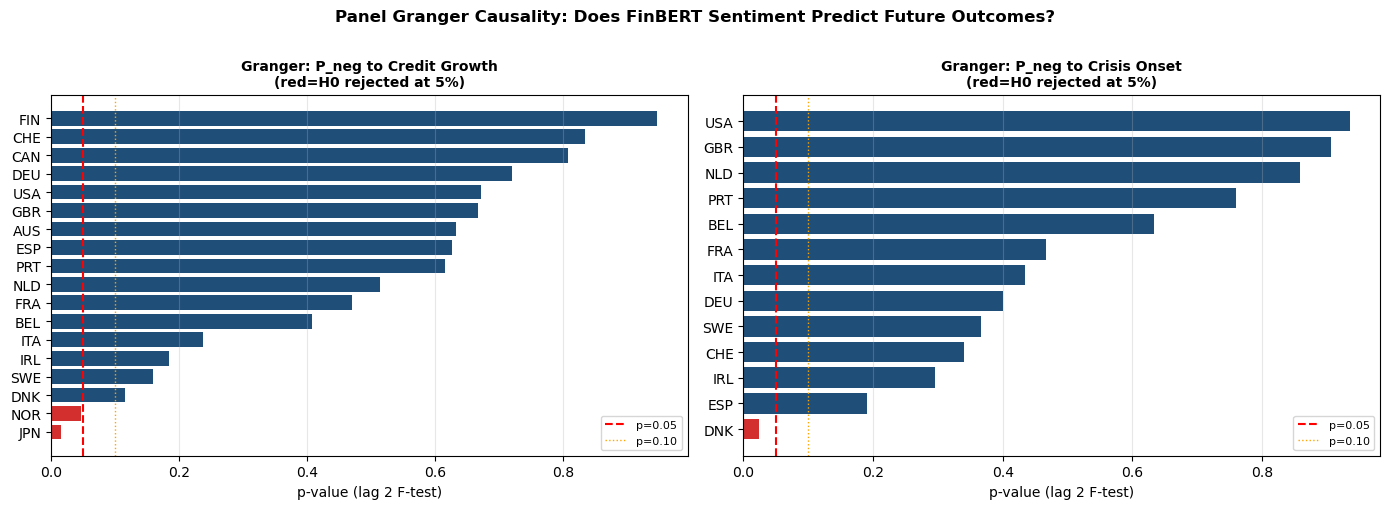

Saved granger_causality.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (ocol, olabel) in zip(axes,
        [('tloans_gr','P_neg to Credit Growth'),('crisisjst','P_neg to Crisis Onset')]):
    p_col = f'p_lag2_{ocol}'
    if p_col not in granger_df.columns:
        ax.text(0.5,0.5,'No data',ha='center',transform=ax.transAxes); continue
    plot_df = granger_df[['country',p_col]].dropna().sort_values(p_col)
    colors  = ['#d32f2f' if p<0.05 else '#1F4E79' for p in plot_df[p_col]]
    ax.barh(plot_df['country'], plot_df[p_col], color=colors)
    ax.axvline(0.05, color='red', linestyle='--', lw=1.5, label='p=0.05')
    ax.axvline(0.10, color='orange', linestyle=':', lw=1, label='p=0.10')
    ax.set_xlabel('p-value (lag 2 F-test)', fontsize=10)
    ax.set_title(f'Granger: {olabel}\n(red=H0 rejected at 5%)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True,alpha=0.3,axis='x')
plt.suptitle('Panel Granger Causality: Does FinBERT Sentiment Predict Future Outcomes?',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/'granger_causality.png', dpi=150, bbox_inches='tight')
plt.show(); print('Saved granger_causality.png')

## Cell 6 — Pooled Panel F-test

In [11]:
# ── CORRECTED pooled panel Granger test ──────────────────────────────────
# Original error: used tloans_gr lags as controls for BOTH outcomes,
# including crisisjst — misspecified. When testing P_neg -> crisisjst,
# the restricted model must use CRISIS ONSET own-lags, not credit growth.
# Fix: outcome-appropriate own-lags in restricted model.

df_pool = df[["iso","year","tloans_gr","crisisjst","P_neg"]].copy()

# Compute all required lags
df_pool["P_neg_lag1"]     = df_pool.groupby("iso")["P_neg"].shift(1)
df_pool["P_neg_lag2"]     = df_pool.groupby("iso")["P_neg"].shift(2)
df_pool["tloans_gr_lag1"] = df_pool.groupby("iso")["tloans_gr"].shift(1)
df_pool["tloans_gr_lag2"] = df_pool.groupby("iso")["tloans_gr"].shift(2)
df_pool["crisisjst_lag1"] = df_pool.groupby("iso")["crisisjst"].shift(1)
df_pool["crisisjst_lag2"] = df_pool.groupby("iso")["crisisjst"].shift(2)
df_pool = df_pool.dropna()
print(f"Pooled observations: {len(df_pool)}")
print()

# Outcome-specific controls — this is the critical fix
CONTROLS = {
    "tloans_gr":  ["tloans_gr_lag1",  "tloans_gr_lag2"],   # credit controls
    "crisisjst":  ["crisisjst_lag1",   "crisisjst_lag2"],   # crisis controls (CORRECTED)
}
SENT_VARS = ["P_neg_lag1", "P_neg_lag2"]

for outcome, olabel in [("tloans_gr","Credit growth"),("crisisjst","Crisis onset")]:
    own_lags = CONTROLS[outcome]
    y = df_pool[outcome]
    if y.std() < 1e-6:
        print(f"{olabel}: insufficient variance — skip")
        continue
    X_r = add_constant(df_pool[own_lags])
    X_u = add_constant(df_pool[own_lags + SENT_VARS])
    try:
        rss_r = OLS(y, X_r).fit().ssr
        res_u = OLS(y, X_u).fit()
        rss_u = res_u.ssr
        n,k_u,k_r = len(y),X_u.shape[1],X_r.shape[1]
        F     = ((rss_r-rss_u)/(k_u-k_r)) / (rss_u/(n-k_u))
        p_val = 1 - stats.f.cdf(F, k_u-k_r, n-k_u)
        verdict = "Reject H0" if p_val < 0.05 else "Fail to reject H0"
        print(f"Pooled panel: P_neg -> {olabel}")
        print(f"  Controls (corrected): {own_lags}")
        print(f"  F={F:.4f}  p={p_val:.4f}  -> {verdict}")
        print()
    except Exception as e:
        print(f"Error: {e}")

print("NOTE: LPM used for binary crisis outcome. Per-country tests in Cell 3 are primary evidence.")

Pooled observations: 378

Pooled panel: P_neg -> Credit growth
  Controls (corrected): ['tloans_gr_lag1', 'tloans_gr_lag2']
  F=0.7782  p=0.4600  -> Fail to reject H0

Pooled panel: P_neg -> Crisis onset
  Controls (corrected): ['crisisjst_lag1', 'crisisjst_lag2']
  F=2.5309  p=0.0810  -> Fail to reject H0

NOTE: LPM used for binary crisis outcome. Per-country tests in Cell 3 are primary evidence.


## Cell 7 — Dissertation Guidance

In [13]:
print('='*65)
print(' NB07 Granger Causality COMPLETE')
print('='*65)
print()
print('HOW TO USE IN DISSERTATION:')
print()
print('Chapter 3 (Methodology), Section: Justification for Sentiment')
print('  Cite Granger (1969). Report per-country test results.')
print('  If H0 rejected for credit growth: sentiment Granger-causes')
print('  credit dynamics -> supports Morris-Shin (2002) causal chain.')
print('  If NOT rejected: note this and explain sentiment may still')
print('  carry signal not captured through the credit channel alone.')
print()
print('Suggested text:')
print('  Granger causality tests were applied to each of the 18 sample')
print('  economies to assess whether lagged FinBERT P_neg Granger-causes')
print('  credit growth and crisis onset beyond their own histories')
print('  (2 lags, annual panel, Granger 1969).')
print()
print(f'Outputs:')
print(f'  {OUT_DIR}/granger_results.csv')
print(f'  {FIG_DIR}/granger_causality.png')

 NB07 Granger Causality COMPLETE

HOW TO USE IN DISSERTATION:

Chapter 3 (Methodology), Section: Justification for Sentiment
  Cite Granger (1969). Report per-country test results.
  If H0 rejected for credit growth: sentiment Granger-causes
  credit dynamics -> supports Morris-Shin (2002) causal chain.
  If NOT rejected: note this and explain sentiment may still
  carry signal not captured through the credit channel alone.

Suggested text:
  Granger causality tests were applied to each of the 18 sample
  economies to assess whether lagged FinBERT P_neg Granger-causes
  credit growth and crisis onset beyond their own histories
  (2 lags, annual panel, Granger 1969).

Outputs:
  C:\Users\Owner\OneDrive\dissertation\data\processed/granger_results.csv
  C:\Users\Owner\OneDrive\dissertation\figures\sentiment_improved/granger_causality.png
